# German Compound Decomposition Portfolio Walk-Through

## Executive Summary
German **Determinativkomposita** (determinative compounds) are highly productive: speakers can create long, semantically precise nouns by composing morphemes. This flexibility is linguistically elegant but computationally difficult.

In practical NLP systems, compound formation introduces three recurring challenges:
- **Data sparsity**: many valid compounds appear rarely in training corpora.
- **High OOV rates**: even strong token-level models fail when compounds are unseen.
- **Boundary uncertainty**: segmentation points are not always explicit and may involve linking morphemes or stem alternations.

This notebook demonstrates a production-style decomposition pipeline using `GermanCompoundDecomposer`, with emphasis on linguistic interpretability and statistical disambiguation.

In [1]:
from __future__ import annotations

import importlib.util
import json
from pathlib import Path

def _ensure_package(module_name: str, install_hint: str) -> None:
    # Fail early with an actionable message so notebook execution does not
    # continue into harder-to-debug import errors in later cells.
    if importlib.util.find_spec(module_name) is None:
        raise ImportError(
            f"Missing optional dependency '{module_name}'. "
            f"Install it with: {install_hint}"
        )

# Keep dependency checks explicit for reproducible notebook setup.
_ensure_package("pandas", "pip install pandas")
_ensure_package("matplotlib", "pip install matplotlib")

import pandas as pd
import matplotlib.pyplot as plt

try:
    from german_compound_decomposer import GermanCompoundDecomposer
except ModuleNotFoundError as exc:
    # Provide a project-local fallback hint instead of a generic import error.
    candidate_path = Path.cwd() / "german_compound_decomposer.py"
    if not candidate_path.exists():
        raise ModuleNotFoundError(
            "Could not import german_compound_decomposer.py from the current working directory. "
            "Open this notebook from projects/German_Compound_Decomposition or adjust PYTHONPATH."
        ) from exc
    raise

# Avoid truncating long component strings in DataFrame output.
pd.set_option("display.max_colwidth", 200)
print("Environment setup complete.")

Environment setup complete.


In [2]:
decomposer = GermanCompoundDecomposer(use_spacy=False)

# Use a controlled demo lexicon so examples are deterministic and the notebook
# behavior does not depend on external dictionaries or model downloads.
decomposer._lemma_set.update(
    {
        "haupt",
        "bahnhof",
        "arbeit",
        "platz",
        "buch",
        "bücher",
        "regal",
        "stau",
        "staub",
        "becken",
        "ecken",
        "recht",
        "schutz",
        "versicherung",
        "gesellschaft",
    }
)
# Ensure recursion cache reflects the updated lexicon state.
decomposer._best_candidate.cache_clear()

baseline_word = "Hauptbahnhof"
baseline_result = decomposer.decompose(baseline_word)

# Pretty-print typed output so component roles are easy to inspect.
print(json.dumps(baseline_result, ensure_ascii=False, indent=2))

{
  "original_word": "Hauptbahnhof",
  "components": [
    {
      "text": "haupt",
      "type": "modifier"
    },
    {
      "text": "bahnhof",
      "type": "head"
    }
  ],
  "confidence_score": 0.0039
}


## Interactive Stress-Testing: Linguistic Phenomena

This section probes three high-impact sources of decomposition difficulty:

1. **Fugenlaute (inter-morphemic links)**
   German compounds can insert linking elements such as `-s-`, `-n-`, `-en-`, or `-er-` between stems (e.g., *Arbeit + s + Platz*).
2. **Stem and vocalic mutation**
   Morphological realization may differ from the citation form, including umlaut alternations (e.g., *Buch* vs. *Bücher*).
3. **Structural ambiguity**
   A surface form can support multiple segmentations with different semantic plausibility. A statistical path score helps prioritize linguistically plausible analyses over accidental string matches.

In [3]:
target_words = [
    "Arbeitsplatz",
    "Bücherregal",
    "Staubecken",
    "Rechtsschutzversicherungsgesellschaft",
]

batch_results = [decomposer.decompose(word) for word in target_words]

def _flatten_result(result: dict) -> dict:
    components = result["components"]
    # Split lexical vs linker components to support multiple analysis views
    # in one compact table row.
    lexical_components = [c["text"] for c in components if c["type"] != "fugenlaut"]
    head_candidates = [c["text"] for c in components if c["type"] == "head"]
    # Defensive default keeps table schema stable even for malformed outputs.
    head = head_candidates[-1] if head_candidates else ""
    return {
        "Original Word": result["original_word"],
        "Split Components": " + ".join(c["text"] for c in components),
        "Identified Head": head,
        "Confidence Score": round(float(result["confidence_score"]), 4),
        "Lexical Components": " | ".join(lexical_components),
    }

results_table = pd.DataFrame([_flatten_result(item) for item in batch_results])
results_table = results_table.sort_values(by="Confidence Score", ascending=False).reset_index(drop=True)

# Heatmap-like styling highlights confidence ranking at a glance.
styled_results = results_table.style.format({"Confidence Score": "{:.4f}"}).background_gradient(
    subset=["Confidence Score"],
    cmap="YlGn",
)
styled_results

,Original Word,Split Components,Identified Head,Confidence Score,Lexical Components
0,Arbeitsplatz,arbeit + s + platz,platz,1.0000,arbeit | platz
1,Staubecken,stau + becken,becken,0.5603,stau | becken
2,Bücherregal,buch + er + regal,regal,0.1008,buch | regal
3,Rechtsschutzversicherungsgesellschaft,recht + s + schutz + versicherung + s + gesellschaft,gesellschaft,0.0585,recht | schutz | versicherung | gesellschaft


,Path,Probability
0,stau + becken,0.560264
1,staub + ecken,0.028840


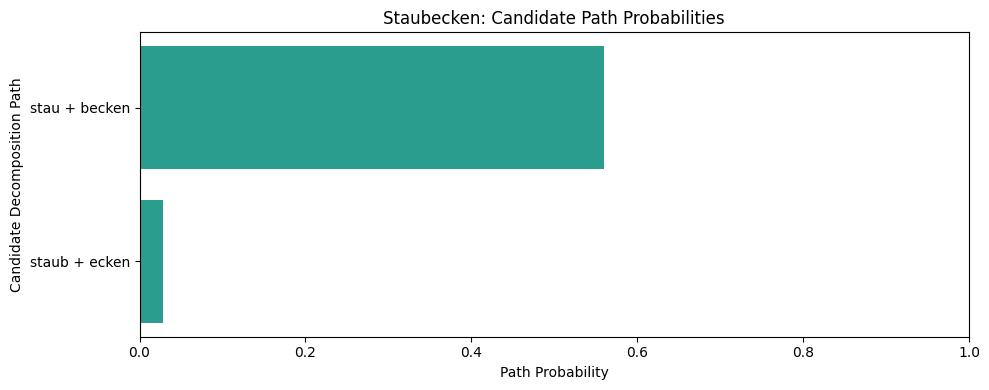

In [4]:
from dataclasses import dataclass
from functools import lru_cache

@dataclass(frozen=True)
class _DemoCandidate:
    components: tuple[tuple[str, bool], ...]
    path_probability: float

def enumerate_candidate_paths(word: str, model: GermanCompoundDecomposer) -> pd.DataFrame:
    normalized = model._normalize(word)

    @lru_cache(maxsize=16384)
    def _all_paths(surface: str) -> tuple[_DemoCandidate, ...]:
        if len(surface) < model.min_component_len:
            return tuple()

        candidates: list[_DemoCandidate] = []

        # Option A: keep the segment atomic if it is a valid lexical unit.
        for lexical in model._lexical_matches(surface):
            parts = ((lexical.lemma, False),)
            candidates.append(
                _DemoCandidate(
                    components=parts,
                    path_probability=model._calculate_path_probability(parts),
                )
            )

        # Option B: recursively split right-to-left to mirror head-final behavior.
        for split_idx in range(len(surface) - model.min_component_len, model.min_component_len - 1, -1):
            left_full = surface[:split_idx]
            right_surface = surface[split_idx:]

            right_candidates = _all_paths(right_surface)
            if not right_candidates:
                continue

            for fugen in model._FUGENLAUTE:
                if fugen and not left_full.endswith(fugen):
                    continue

                # Remove linker from left span before lexical validation.
                left_surface = left_full[: -len(fugen)] if fugen else left_full
                if len(left_surface) < model.min_component_len:
                    continue

                left_candidates = _all_paths(left_surface)
                if not left_candidates:
                    continue

                # Cartesian merge captures all structurally valid compositions.
                for left_candidate in left_candidates:
                    for right_candidate in right_candidates:
                        merged_parts = list(left_candidate.components)
                        if fugen:
                            merged_parts.append((fugen, True))
                        merged_parts.extend(right_candidate.components)
                        merged_tuple = tuple(merged_parts)
                        candidates.append(
                            _DemoCandidate(
                                components=merged_tuple,
                                path_probability=model._calculate_path_probability(merged_tuple),
                            )
                        )

        # Deduplicate by structure and keep the highest-probability instance.
        dedup: dict[tuple[tuple[str, bool], ...], _DemoCandidate] = {}
        for candidate in candidates:
            previous = dedup.get(candidate.components)
            if previous is None or candidate.path_probability > previous.path_probability:
                dedup[candidate.components] = candidate

        return tuple(dedup.values())

    all_candidates = list(_all_paths(normalized))
    if not all_candidates:
        return pd.DataFrame(columns=["Path", "Probability"])

    records = []
    for candidate in all_candidates:
        # Bracket linker elements so boundary phenomena are visually explicit.
        path = " + ".join(
            part if not is_fugen else f"[{part}]"
            for part, is_fugen in candidate.components
        )
        records.append({"Path": path, "Probability": candidate.path_probability})

    candidate_df = pd.DataFrame(records).sort_values(by="Probability", ascending=False).reset_index(drop=True)
    return candidate_df

staubecken_candidates = enumerate_candidate_paths("Staubecken", decomposer)
display(staubecken_candidates.head(10))

top_n = min(10, len(staubecken_candidates))
plot_df = staubecken_candidates.head(top_n).iloc[::-1]

plt.figure(figsize=(10, max(4, top_n * 0.5)))
plt.barh(plot_df["Path"], plot_df["Probability"], color="#2a9d8f")
plt.xlabel("Path Probability")
plt.ylabel("Candidate Decomposition Path")
plt.title("Staubecken: Candidate Path Probabilities")
plt.xlim(0.0, 1.0)
plt.tight_layout()
plt.show()

## Summary: Downstream Value for NLP Systems

Compound decomposition improves both robustness and interpretability in morphologically rich settings.

- **Machine Translation**: cleaner morpheme-level alignment supports better lexical choice and reduces hallucinated translations for rare compounds.
- **Information Retrieval**: indexing both full compounds and decomposed constituents improves recall without sacrificing precision.
- **Model Generalization**: explicit handling of Fugenlaute, stem alternations, and ambiguity reduces OOV brittleness and supports more stable behavior in production pipelines.

In short, decomposition acts as a linguistically informed normalization layer between raw text and downstream modeling.